In [1]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.8 MB/s eta 0:00:00


In [2]:
import os
import numpy as np

# 1. Khai báo và tạo thư mục 'data' nằm ngay trong thư mục project hiện tại
PROJECT_DATA_DIR = './data'
os.makedirs(PROJECT_DATA_DIR, exist_ok=True)

# =========================================================
# 2. TẢI DIGIT MNIST VÀ FASHION MNIST
# =========================================================
# MẸO: Ép thư viện Keras đổi "nhà" từ ổ đĩa hệ thống sang thư mục project của bạn
os.environ['KERAS_HOME'] = PROJECT_DATA_DIR

from tensorflow.keras.datasets import mnist, fashion_mnist

print("Đang tải Digit MNIST vào project...")
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

print("Đang tải Fashion MNIST vào project...")
(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = fashion_mnist.load_data()
# Keras sẽ tự động tạo một thư mục con tên là 'datasets' bên trong thư mục 'data' của bạn.
# Các file tải về sẽ nằm ở: ./data/datasets/


# =========================================================
# 3. TẢI PNEUMONIA MNIST (MEDICAL)
# =========================================================
import medmnist
from medmnist import PneumoniaMNIST

print("Đang tải Pneumonia MNIST vào project...")
# Với MedMNIST, chỉ cần truyền biến root là xong
train_pneumonia = PneumoniaMNIST(split='train', download=True, root=PROJECT_DATA_DIR)
test_pneumonia  = PneumoniaMNIST(split='test',  download=True, root=PROJECT_DATA_DIR)

# Trích xuất ra ma trận Numpy
X_train_pneumonia = train_pneumonia.imgs
y_train_pneumonia = train_pneumonia.labels.squeeze()

X_test_pneumonia = test_pneumonia.imgs
y_test_pneumonia = test_pneumonia.labels.squeeze()

print("\n🎉 HOÀN TẤT! Toàn bộ dữ liệu đã được cất gọn gàng vào thư mục:", PROJECT_DATA_DIR)

Đang tải Digit MNIST vào project...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Đang tải Fashion MNIST vào project...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Đang tải Pneumonia MNIST vào project...


100%|██████████| 4.17M/4.17M [00:07<00:00, 566kB/s]



🎉 HOÀN TẤT! Toàn bộ dữ liệu đã được cất gọn gàng vào thư mục: ./data


In [3]:
def describe_raw(name, X, y):
    print(f"\n{name}")
    print(f"  X shape: {X.shape}, dtype: {X.dtype}")
    print(f"  y shape: {y.shape}, dtype: {y.dtype}")
    print(f"  X min/max: {X.min()} / {X.max()}")
    print(f"  Unique labels: {np.unique(y)}")

describe_raw("Digit MNIST (raw)", X_train_digit, y_train_digit)
describe_raw("Fashion MNIST (raw)", X_train_fashion, y_train_fashion)
describe_raw("Pneumonia MNIST (raw)", X_train_pneumonia, y_train_pneumonia)


Digit MNIST (raw)
  X shape: (60000, 28, 28), dtype: uint8
  y shape: (60000,), dtype: uint8
  X min/max: 0 / 255
  Unique labels: [0 1 2 3 4 5 6 7 8 9]

Fashion MNIST (raw)
  X shape: (60000, 28, 28), dtype: uint8
  y shape: (60000,), dtype: uint8
  X min/max: 0 / 255
  Unique labels: [0 1 2 3 4 5 6 7 8 9]

Pneumonia MNIST (raw)
  X shape: (4708, 28, 28), dtype: uint8
  y shape: (4708,), dtype: uint8
  X min/max: 0 / 255
  Unique labels: [0 1]


# Setup dataloader

In [4]:
import cv2

def hog_features(train_data):
	reshaped_data = train_data.reshape(-1, 28, 28)
	win_size = reshaped_data[0].shape
	cell_size = (4, 4)
	block_size = (8, 8)
	block_stride = (4, 4)
	num_bins = 9

	hog = cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, num_bins)

	num_images = reshaped_data.shape[0]
	image_size = len(hog.compute(reshaped_data[0].astype(np.uint8)))
	hog_training_data = np.zeros((num_images, image_size))

	for i, image in enumerate(reshaped_data):
		try:
			hog_descriptor = hog.compute(image.astype(np.uint8))
			hog_training_data[i] = hog_descriptor.flatten()
		except Exception as e:
			# break
			print(f"Error processing image {i}: {e}")
	return hog_training_data


def hog_features_fusion(train_data):
	reshaped_data = train_data.reshape(-1, 28, 28)
	win_size = reshaped_data[0].shape
	cell_size = (4, 4)
	block_size = (8, 8) # dùng 4 cell để normalize
	block_stride = (4, 4)
	num_bins = 9

	hog = cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, num_bins)

	num_images = reshaped_data.shape[0]
	image_size = len(hog.compute(reshaped_data[0].astype(np.uint8))) + len(reshaped_data[0].reshape(-1).flatten())
	hog_training_data = np.zeros((num_images, image_size))

	for i, image in enumerate(reshaped_data):
		try:
			hog_descriptor = hog.compute(image.astype(np.uint8))
			hog_training_data[i] = np.concatenate((hog_descriptor.flatten(), image.reshape(-1).flatten() / 255))
		except Exception as e:
			# break
			print(f"Error processing image {i}: {e}")
	return hog_training_data


In [5]:
X_train_digit_hog = hog_features(X_train_digit)
X_test_digit_hog = hog_features(X_test_digit)

In [6]:
describe_raw("Digit MNIST (hog)", X_train_digit_hog, y_train_digit)



Digit MNIST (hog)
  X shape: (60000, 1296), dtype: float64
  y shape: (60000,), dtype: uint8
  X min/max: 0.0 / 0.9950248599052429
  Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [8]:

class baseline_ANN_2_hidden_layer(nn.Module):
  def __init__(self, input_size, hidden_size=512, output_size=10):
    super(baseline_ANN_2_hidden_layer, self).__init__()

    self.fc1 = nn.Linear(input_size, hidden_size)
    self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
    self.fc3 = nn.Linear(hidden_size // 2, 128)
    self.fc4 = nn.Linear(128, output_size)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = self.fc4(x) # Removed F.sigmoid(x) for CrossEntropyLoss
    return x

# improve baseline with using the same model with hog featured inputs

# class ANN_HOG_Digit(nn.Module):
#     def __init__(self, input_size, output_size):
#         super(ANN_HOG_Digit, self).__init__()

#         self.fc

In [9]:
def acc(model, input, label):
  model.eval()
  predict_outputs = model(torch.flatten(torch.tensor(input, dtype=torch.float32), start_dim=1).to(device) / 255.0)
  labels = torch.tensor(label).to(device)

  _, predicted = torch.max(predict_outputs, 1)
  correct = (labels == predicted).sum().item()
  total = len(labels)

  return correct/total

def train_baseline(model, X_train, y_train, criterion=nn.CrossEntropyLoss(), epochs=100, lr = 0.001):
  """
    X_train, y_train: torch.tensor
    X_train.shape = (N, 28, 28): -> this will be flatten
  """
  print("training")
  model.train()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  inputs = torch.flatten(X_train, start_dim=1).to(device) # Move inputs to device
  labels = y_train.to(device) # Move labels to device

  for epoch in range(epochs):
    outputs = model(inputs)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:

      _, predicted = torch.max(outputs, 1)
      correct = (labels == predicted).sum().item()
      acc = correct / len(labels)
      print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Acc: {acc:.4f}')
  return


In [10]:
# setup
digit_model = baseline_ANN_2_hidden_layer(1296, 512, 10)
criterion = nn.CrossEntropyLoss()
digit_model.to(device)

train_baseline(digit_model, torch.tensor(X_train_digit_hog, dtype=torch.float32) / 255.0, torch.tensor(y_train_digit, dtype=torch.long), epochs=500)

training
Epoch [10/500], Loss: 2.3011, Acc: 0.1124
Epoch [20/500], Loss: 2.2981, Acc: 0.1124
Epoch [30/500], Loss: 2.2849, Acc: 0.1124
Epoch [40/500], Loss: 2.2336, Acc: 0.2178
Epoch [50/500], Loss: 2.0910, Acc: 0.3483
Epoch [60/500], Loss: 1.8113, Acc: 0.3816
Epoch [70/500], Loss: 1.4757, Acc: 0.4352
Epoch [80/500], Loss: 1.2314, Acc: 0.5444
Epoch [90/500], Loss: 1.0802, Acc: 0.5942
Epoch [100/500], Loss: 0.9754, Acc: 0.6324
Epoch [110/500], Loss: 0.8941, Acc: 0.6675
Epoch [120/500], Loss: 0.8253, Acc: 0.6997
Epoch [130/500], Loss: 0.7639, Acc: 0.7307
Epoch [140/500], Loss: 0.7097, Acc: 0.7578
Epoch [150/500], Loss: 0.6603, Acc: 0.7807
Epoch [160/500], Loss: 0.6134, Acc: 0.8027
Epoch [170/500], Loss: 0.5680, Acc: 0.8211
Epoch [180/500], Loss: 0.5211, Acc: 0.8391
Epoch [190/500], Loss: 0.4711, Acc: 0.8565
Epoch [200/500], Loss: 0.4196, Acc: 0.8737
Epoch [210/500], Loss: 0.3724, Acc: 0.8875
Epoch [220/500], Loss: 0.3332, Acc: 0.8994
Epoch [230/500], Loss: 0.3019, Acc: 0.9087
Epoch [240/

In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model_metrics(model, X_test, y_test, num_classes):
  model.eval() # Set model to evaluation mode
  with torch.no_grad():
    # Prepare test data and move to device
    inputs = torch.flatten(torch.tensor(X_test, dtype=torch.float32), start_dim=1).to(device) / 255.0
    labels = torch.tensor(y_test).to(device)

    # Get predictions
    outputs = model(inputs)
    _, predicted = torch.max(outputs, 1)

    # Move predictions and labels back to CPU for scikit-learn metrics
    predicted_cpu = predicted.cpu().numpy()
    labels_cpu = labels.cpu().numpy()

    # Calculate metrics
    accuracy = (labels_cpu == predicted_cpu).sum() / len(labels_cpu)
    f1 = f1_score(labels_cpu, predicted_cpu, average='weighted' if num_classes > 2 else 'binary')
    precision = precision_score(labels_cpu, predicted_cpu, average='weighted' if num_classes > 2 else 'binary')
    recall = recall_score(labels_cpu, predicted_cpu, average='weighted' if num_classes > 2 else 'binary')
    cm = confusion_matrix(labels_cpu, predicted_cpu)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return accuracy, f1, precision, recall, cm

Metrics for Digit MNIST Model:
Accuracy: 0.8016
F1 Score: 0.7877
Precision: 0.8652
Recall: 0.8016


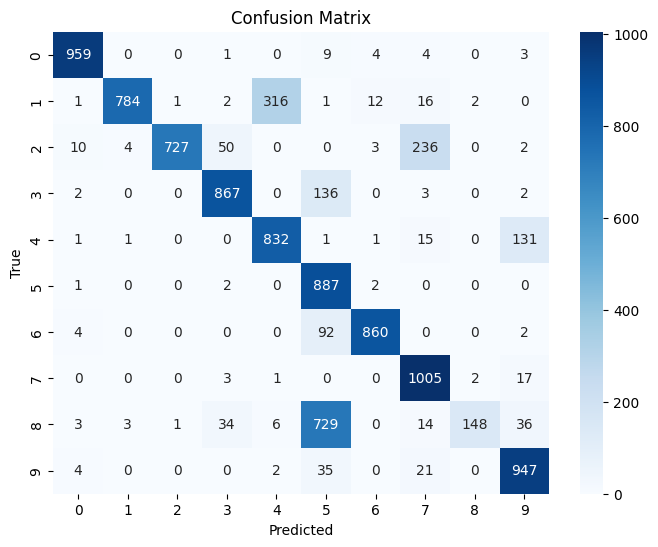

In [12]:
print("Metrics for Digit MNIST Model:")
digit_metrics = evaluate_model_metrics(digit_model, X_test_digit_hog * 255, y_test_digit, num_classes=10)

After trained and re-evaluated with the hog feature transform, every metric has slight improvement, and thus, some classes that previously usually got miss-classified now become more distinguish (4, 9) but new pairs get miss-labeled (3,9)

In [13]:
def get_wrong_predict(model, X_test, y_test, num_classes):
  model.eval() # Set model to evaluation mode
  with torch.no_grad():
    # Prepare test data and move to device
    inputs = torch.flatten(torch.tensor(X_test, dtype=torch.float32), start_dim=1).to(device) / 255.0
    labels = torch.tensor(y_test).to(device)

    # Get predictions
    outputs = model(inputs)
    _, predicted = torch.max(outputs, 1)

    # Move predictions and labels back to CPU for scikit-learn metrics
    predicted_cpu = predicted.cpu().numpy()
    labels_cpu = labels.cpu().numpy()

    # Calculate metrics

    total = len(y_test)
    mask = (predicted_cpu != labels_cpu)

    GT = labels_cpu[mask]
    MISS = predicted[mask]
    index = [i for i, v in enumerate(mask) if v == 1]

    return [(GT[i], MISS[i], index[i]) for i in range(len(GT))]

wrong_samples = get_wrong_predict(digit_model, X_test_digit_hog, y_test_digit, 10)
print(len(wrong_samples))


330


In [14]:
cnt = [[[] for i in range(10)] for j in range(10)]
for t, f, i in wrong_samples:
  cnt[t][f].append(i)

lens = []

for i in range(10):
  for j in range(10):
    if len(cnt[i][j]) > 0:
      lens.append((i, j, len(cnt[i][j])))

lens = sorted(lens, key=lambda x: -x[2])
print(lens)

[(3, 8, 22), (7, 2, 17), (9, 8, 17), (5, 3, 14), (8, 3, 14), (1, 2, 13), (5, 8, 13), (9, 4, 13), (4, 9, 12), (9, 7, 12), (3, 5, 11), (8, 5, 11), (4, 1, 10), (8, 1, 10), (2, 7, 8), (7, 9, 8), (8, 9, 8), (0, 6, 7), (2, 1, 6), (2, 3, 6), (8, 0, 6), (5, 6, 5), (9, 0, 5), (9, 5, 5), (3, 2, 4), (6, 0, 4), (6, 4, 4), (6, 5, 4), (7, 4, 4), (7, 8, 4), (0, 2, 3), (1, 8, 3), (2, 0, 3), (3, 7, 3), (7, 1, 3), (8, 7, 3), (0, 4, 2), (0, 7, 2), (0, 8, 2), (1, 6, 2), (2, 6, 2), (2, 8, 2), (4, 0, 2), (4, 7, 2), (5, 0, 2), (5, 9, 2), (6, 8, 2), (9, 1, 2), (9, 3, 2), (0, 5, 1), (1, 4, 1), (3, 0, 1), (3, 9, 1), (4, 2, 1), (4, 6, 1), (6, 1, 1), (8, 2, 1), (8, 4, 1)]


# Experiment with hog 12 bins

Metrics for Digit MNIST Model (concat hog + original):
- Accuracy: 0.9767
- F1 Score: 0.9767
- Precision: 0.9767
- Recall: 0.9767

[(5, 3, 16), (7, 2, 10), (8, 3, 8), (9, 3, 8), (2, 8, 7), (4, 9, 7), (6, 4, 7), (9, 4, 7), (7, 9, 6), (3, 8, 5), (6, 2, 5), (6, 5, 5), (9, 5, 5), (0, 6, 4), (1, 8, 4), (2, 0, 4), (2, 1, 4), (3, 2, 4), (3, 7, 4), (3, 9, 4), (4, 6, 4), (6, 0, 4), (6, 1, 4), (7, 1, 4), (8, 0, 4), (9, 0, 4), (9, 7, 4), (9, 8, 4), (1, 2, 3), (2, 6, 3), (2, 7, 3), (3, 5, 3), (4, 7, 3), (5, 8, 3), (7, 3, 3), (8, 2, 3), (8, 4, 3), (8, 5, 3), (8, 7, 3), (8, 9, 3), (0, 3, 2), (0, 8, 2), (1, 6, 2), (2, 3, 2), (2, 4, 2), (3, 1, 2), (4, 2, 2), (5, 0, 2), (5, 6, 2), (7, 8, 2), (8, 6, 2), (9, 1, 2), (0, 5, 1), (0, 7, 1), (0, 9, 1), (1, 5, 1), (2, 9, 1), (3, 0, 1), (4, 0, 1), (4, 1, 1), (4, 3, 1), (4, 5, 1), (4, 8, 1), (5, 1, 1), (5, 4, 1), (5, 7, 1), (6, 3, 1), (6, 8, 1), (7, 0, 1), (7, 4, 1)]


Metrics for Digit MNIST Model (Hog only):
- Accuracy: 0.9793
- F1 Score: 0.9793
- Precision: 0.9793
- Recall: 0.9793


Missed classes: [(9, 8, 13), (9, 3, 12), (0, 6, 9), (5, 3, 9), (6, 0, 9), (1, 2, 8), (4, 9, 8), (7, 2, 8), (9, 4, 8), (2, 0, 7), (3, 5, 7), (6, 5, 7), (9, 5, 7), (9, 7, 7), (2, 1, 6), (3, 8, 6), (8, 9, 6), (0, 2, 5), (5, 0, 5), (7, 9, 5), (8, 0, 5), (8, 2, 5), (8, 3, 5), (2, 3, 4), (7, 3, 4), (7, 4, 4), (4, 7, 3), (5, 6, 3), (5, 8, 3), (5, 9, 3), (6, 4, 3), (7, 1, 3), (8, 5, 3), (8, 6, 3), (9, 1, 3), (1, 6, 2), (1, 8, 2), (2, 7, 2), (2, 8, 2), (3, 2, 2), (3, 7, 2), (4, 1, 2), (6, 1, 2), (6, 8, 2), (8, 7, 2), (9, 2, 2), (0, 3, 1), (1, 0, 1), (1, 4, 1), (3, 9, 1), (4, 2, 1), (4, 6, 1), (4, 8, 1), (7, 8, 1), (8, 4, 1), (9, 0, 1)]

With the idea of the hog miss-classifying because of , i tried the hog feature, and concat it with the original image

# Result with hog 9 bins

The hog alone with 9 bins setting get the better performance than the previouse 12 bins setting, this could becuase of the model size is not big enough for such high dimemsion input as 12 bins, which generated 1748+ feature vector for each image, while this approach uses the 1296 features vector:

- Accuracy: 0.9808
- F1 Score: 0.9808
- Precision: 0.9808
- Recall: 0.9808


# Perform data augmentation

In [15]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

class CustomDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        """
        Args:
            data (np.array): Mảng ảnh shape (N, 28, 28) hoặc (N, 784)
            labels (np.array): Mảng nhãn shape (N,)
            transform (callable, optional): Các phép biến đổi PyTorch
        """
        # Đảm bảo dữ liệu ảnh ở dạng (N, 28, 28)
        if len(data.shape) == 2:
            self.data = data.reshape(-1, 28, 28).astype(np.uint8)
        else:
            self.data = data.astype(np.uint8)

        self.labels = labels
        self.transform = transform

	      # reshaped_data = train_data.reshape(-1, 28, 28)

        self.hog = None

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Lấy một ảnh và nhãn
        image = self.data[idx]
        label = self.labels[idx]
        image = transforms.ToPILImage()(image)

        # Áp dụng các phép biến đổi nếu có
        if self.transform:
            # transform của PyTorch thường yêu cầu đầu vào là ảnh PIL hoặc Tensor
            # Chúng ta chuyển Numpy -> PIL Image trước
            image = self.transform(image)

        if self.hog is None:

          win_size = (28, 28)
          cell_size = (4, 4)
          block_size = (8, 8) # dùng 4 cell để normalize
          block_stride = (4, 4)
          num_bins = 9
          self.hog = cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, num_bins)

        hog_image = self.hog.compute(np.array(image, dtype=np.uint8)).flatten()

        # Trả về ảnh (lúc này đã là Tensor) và nhãn
        return torch.tensor(hog_image, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [16]:
train_transform = transforms.Compose([
    # 1. Xoay ngẫu nhiên trong khoảng [-10, 10] độ
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)), # Có thể dùng thay Affine trên
])


In [17]:
train_digit_dataset = CustomDataset(X_train_digit, y_train_digit, train_transform)
test_digit_dataset = CustomDataset(X_test_digit, y_test_digit)

In [18]:
train_digit_dataset[0][0].shape

torch.Size([1296])

In [19]:
# def visualize_augmentation(dataset, idx=0, n_samples=5):
#     plt.figure(figsize=(15, 3))

#     # Hiển thị ảnh gốc (không áp dụng transform)
#     # Chúng ta tạm thời bỏ transform để lấy ảnh gốc
#     original_transform = dataset.transform
#     dataset.transform = transforms.ToTensor()
#     orig_img, _ = dataset[idx]

#     plt.subplot(1, n_samples + 1, 1)
#     plt.imshow(orig_img.squeeze().numpy(), cmap='gray')
#     plt.title("Gốc")
#     plt.axis('off')

#     # Áp dụng lại transform và hiển thị n_samples ảnh đã biến đổi
#     dataset.transform = original_transform
#     for i in range(n_samples):
#         aug_img, _ = dataset[idx] # Mỗi lần gọi sẽ ra một biến đổi ngẫu nhiên khác nhau

#         plt.subplot(1, n_samples + 1, i + 2)
#         # Chuyển Tensor (C, H, W) -> (H, W) để vẽ bằng matplotlib
#         plt.imshow(aug_img.squeeze().numpy(), cmap='gray')
#         plt.title(f"Lắc {i+1}")
#         plt.axis('off')

#     plt.tight_layout()
#     plt.show()

# # Hiển thị thử ảnh đầu tiên (index 0) với 5 lần "lắc" khác nhau
# visualize_augmentation(train_digit_dataset, idx=0)

# Training loop

In [20]:
# Training setup



def train_dataset(model, dataloader, criterion=nn.CrossEntropyLoss(), epochs=100, lr = 0.001):
  """
    X_train, y_train: torch.tensor
    X_train.shape = (N, 28, 28): -> this will be flatten
  """
  print("training")
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  for epoch in range(epochs):
    model.train()
    num_batches = 0
    sum_acc = 0
    sum_los = 0

    for i, (X, y) in enumerate(dataloader):
      X, y = X.to(device).flatten(1), y.to(device)
      # print(X.shape)

      preds = model(X)
      loss = criterion(preds, y)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


      ## calculate metrics over batches
      _, predicted = torch.max(preds, 1)
      correct = (y == predicted).sum().item()
      acc = correct / len(y)

      sum_acc += acc
      sum_los += loss.item()
      num_batches += 1


    # if (epoch + 1) % 10 == 0:
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {sum_los / num_batches:.4f}, Acc: {sum_acc / num_batches:.4f}')


dataloader = DataLoader(dataset=train_digit_dataset, batch_size=1024 * 8, num_workers=2, shuffle=True)
augmented_model = baseline_ANN_2_hidden_layer(1296, 512, 10)
augmented_model.to(device)
train_dataset(augmented_model, dataloader, epochs = 20)

training
Epoch [1/20], Loss: 2.1713, Acc: 0.3980
Epoch [2/20], Loss: 1.3586, Acc: 0.6592
Epoch [3/20], Loss: 0.6672, Acc: 0.7890
Epoch [4/20], Loss: 0.4754, Acc: 0.8456
Epoch [5/20], Loss: 0.3892, Acc: 0.8751
Epoch [6/20], Loss: 0.3388, Acc: 0.8914
Epoch [7/20], Loss: 0.3111, Acc: 0.9015
Epoch [8/20], Loss: 0.2844, Acc: 0.9105
Epoch [9/20], Loss: 0.2664, Acc: 0.9167
Epoch [10/20], Loss: 0.2546, Acc: 0.9201
Epoch [11/20], Loss: 0.2403, Acc: 0.9250
Epoch [12/20], Loss: 0.2236, Acc: 0.9299
Epoch [13/20], Loss: 0.2190, Acc: 0.9298
Epoch [14/20], Loss: 0.2101, Acc: 0.9350
Epoch [15/20], Loss: 0.1989, Acc: 0.9380
Epoch [16/20], Loss: 0.1858, Acc: 0.9413
Epoch [17/20], Loss: 0.1832, Acc: 0.9432
Epoch [18/20], Loss: 0.1769, Acc: 0.9438
Epoch [19/20], Loss: 0.1675, Acc: 0.9479
Epoch [20/20], Loss: 0.1616, Acc: 0.9496


Accuracy: 0.9813
F1 Score: 0.9813
Precision: 0.9814
Recall: 0.9813


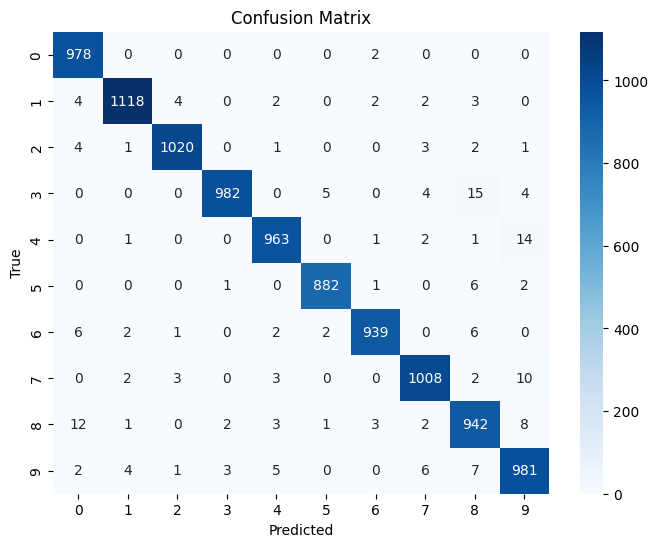

In [21]:
digit_metrics = evaluate_model_metrics(augmented_model, X_test_digit_hog * 255, y_test_digit, num_classes=10)


# With data augmentation and batch training:
- Accuracy: 0.9886
- F1 Score: 0.9886
- Precision: 0.9886
- Recall: 0.9886

# Modified the model - adding batch normalization and dropout

In [22]:

class baseline_ANN_2_batch_norm_dropout(nn.Module):
  def __init__(self, input_size, hidden_size=512, output_size=10, dropout_rate=0.2):
    super(baseline_ANN_2_hidden_layer, self).__init__()

    self.fc1 = nn.Linear(input_size, hidden_size)
    self.bn1 = nn.BatchNorm1d(hidden_size)

    self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
    self.bn2 = nn.BatchNorm1d(hidden_size // 2)

    self.fc3 = nn.Linear(hidden_size // 2, 128)
    self.bn3 = nn.BatchNorm1d(128)

    self.fc4 = nn.Linear(128, output_size)

    self.dropout = nn.Dropout(dropout_rate)

  def forward(self, x):
    # x = self.dropout(F.relu(self.bn1(self.fc1(x))))
    # x = self.dropout(F.relu(self.bn2(self.fc2(x))))

    x = F.relu(self.bn1(self.fc1(x)))
    x = F.relu(self.bn2(self.fc2(x)))
    x = F.relu(self.bn3(self.fc3(x)))
    x = self.fc4(x) # Removed F.sigmoid(x) for CrossEntropyLoss
    return x

# improve baseline with using the same model with hog featured inputs

# class ANN_HOG_Digit(nn.Module):
#     def __init__(self, input_size, output_size):
#         super(ANN_HOG_Digit, self).__init__()

#         self.fc

training
Epoch [1/40], Loss: 2.3408, Acc: 0.2314
Epoch [2/40], Loss: 1.0815, Acc: 0.6581
Epoch [3/40], Loss: 0.6435, Acc: 0.7931
Epoch [4/40], Loss: 0.4117, Acc: 0.8694
Epoch [5/40], Loss: 0.2886, Acc: 0.9084
Epoch [6/40], Loss: 0.2206, Acc: 0.9292
Epoch [7/40], Loss: 0.1780, Acc: 0.9444
Epoch [8/40], Loss: 0.1519, Acc: 0.9536
Epoch [9/40], Loss: 0.1349, Acc: 0.9565
Epoch [10/40], Loss: 0.1221, Acc: 0.9615
Epoch [11/40], Loss: 0.1084, Acc: 0.9661
Epoch [12/40], Loss: 0.0982, Acc: 0.9682
Epoch [13/40], Loss: 0.0877, Acc: 0.9715
Epoch [14/40], Loss: 0.0911, Acc: 0.9713
Epoch [15/40], Loss: 0.0824, Acc: 0.9733
Epoch [16/40], Loss: 0.0803, Acc: 0.9742
Epoch [17/40], Loss: 0.0748, Acc: 0.9762
Epoch [18/40], Loss: 0.0714, Acc: 0.9774
Epoch [19/40], Loss: 0.0703, Acc: 0.9771
Epoch [20/40], Loss: 0.0717, Acc: 0.9776
Epoch [21/40], Loss: 0.0666, Acc: 0.9784
Epoch [22/40], Loss: 0.0634, Acc: 0.9796
Epoch [23/40], Loss: 0.0611, Acc: 0.9807
Epoch [24/40], Loss: 0.0599, Acc: 0.9805
Epoch [25/40], L

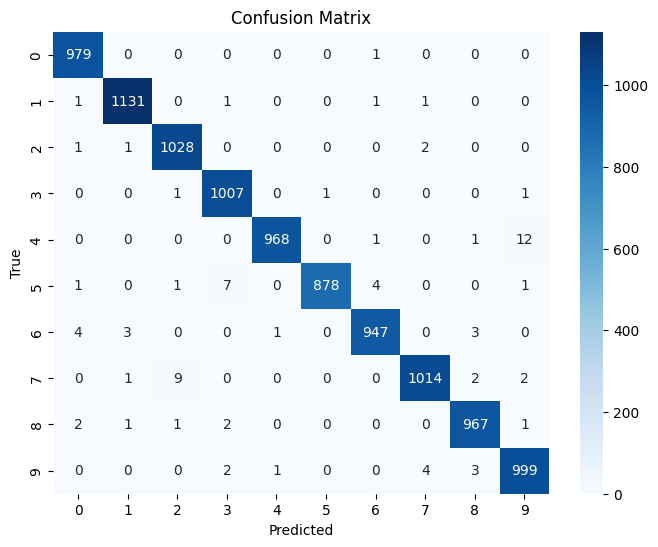

In [23]:
augmented_bn_do_model = baseline_ANN_2_hidden_layer(1296, 512, 10)
augmented_bn_do_model.to(device)
train_dataset(augmented_bn_do_model, dataloader, epochs = 40, lr=0.01) # có batch norm nên phải train lâu hơn
# -> vì những epoch đầu giúp cho mô hình ổn định, nhưng được phép sử dụng learning rate cao hơn
# cải tiến tiếp theo có thể là gắn scheduler
digit_metrics = evaluate_model_metrics(augmented_bn_do_model, X_test_digit_hog * 255, y_test_digit, num_classes=10)


# Kết quả chạy với batch norm và augmentation + hog đạt 99.18% trên tập mnist dataset:
- Accuracy: 0.9918
- F1 Score: 0.9918
- Precision: 0.9918
- Recall: 0.9918

trong đó cặp 7, 2 vẫn còn nhầm lẫn, nhưng có giảm so với những model chạy feature hog bên trên

training
Epoch [1/10], Loss: 0.0399, Acc: 0.9875
Epoch [2/10], Loss: 0.0398, Acc: 0.9873
Epoch [3/10], Loss: 0.0368, Acc: 0.9880
Epoch [4/10], Loss: 0.0365, Acc: 0.9882
Epoch [5/10], Loss: 0.0371, Acc: 0.9877
Epoch [6/10], Loss: 0.0361, Acc: 0.9882
Epoch [7/10], Loss: 0.0347, Acc: 0.9887
Epoch [8/10], Loss: 0.0349, Acc: 0.9884
Epoch [9/10], Loss: 0.0350, Acc: 0.9885
Epoch [10/10], Loss: 0.0344, Acc: 0.9889
Accuracy: 0.9930
F1 Score: 0.9930
Precision: 0.9930
Recall: 0.9930


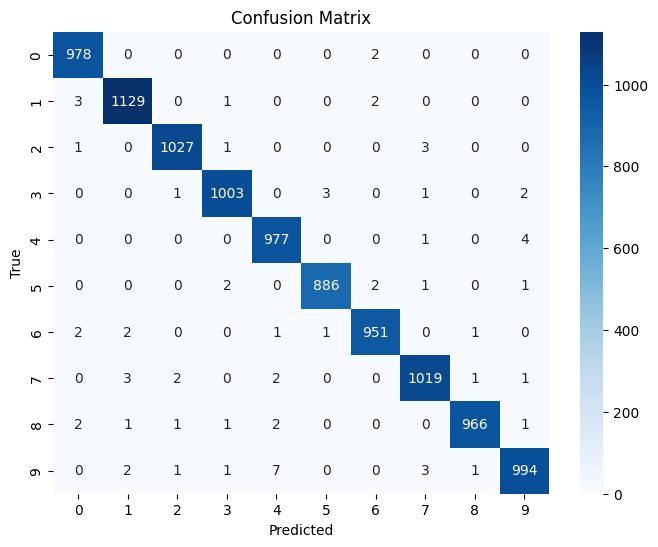

In [24]:
train_dataset(augmented_bn_do_model, dataloader, epochs = 10)
digit_metrics = evaluate_model_metrics(augmented_bn_do_model, X_test_digit_hog * 255, y_test_digit, num_classes=10)


## Train thêm 10 epochs thì kết quả cũng tốt hơn, đây có thể là dấu hiệu để thử nghiệm thêm 1 scheduler và early stopping nếu sau 1 quá trình train không thấy cải thiện

In [32]:
import copy
def train_dataset_early_stopping(model, dataloader, criterion=nn.CrossEntropyLoss(), epochs=100, lr = 0.001, max_to_stop = 5, best_model_path : str = None):
  """
    X_train, y_train: torch.tensor
    X_train.shape = (N, 28, 28): -> this will be flatten
  """
  print("training")
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  last_acc = 0
  cnt_not_improve = 0

  best_loss = float('inf')
  best_model_state_dict = None

  if best_model_path is not None:
    best_model_state_dict = copy.deepcopy(model.state_dict())

  for epoch in range(epochs):
    model.train()
    num_batches = 0
    sum_acc = 0
    sum_los = 0

    for i, (X, y) in enumerate(dataloader):
      X, y = X.to(device).flatten(1), y.to(device)
      # print(X.shape)

      preds = model(X)
      loss = criterion(preds, y)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


      ## calculate metrics over batches
      _, predicted = torch.max(preds, 1)
      correct = (y == predicted).sum().item()
      acc = correct / len(y)

      sum_acc += acc
      sum_los += loss.item()
      num_batches += 1


    # if (epoch + 1) % 10 == 0:
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {sum_los / num_batches:.4f}, Acc: {sum_acc / num_batches:.4f}')

    cur_acc = sum_acc / num_batches
    cur_los = sum_los / num_batches

    if (cur_los < best_loss) and (best_model_path is not None):
      best_model_state_dict = copy.deepcopy(model.state_dict())
      best_loss = cur_los
      torch.save(best_model_state_dict, best_model_path)
      print(f"New best model saved with validation loss: {best_loss:.4f}")

    if cur_acc <= last_acc:
      cnt_not_improve += 1
    else:
      last_acc = cur_acc

    if cnt_not_improve > max_to_stop:
      break

# train_dataset_early_stopping(augmented_bn_do_model, dataloader, epochs = 10)


Accuracy: 0.9939
F1 Score: 0.9939
Precision: 0.9939
Recall: 0.9939


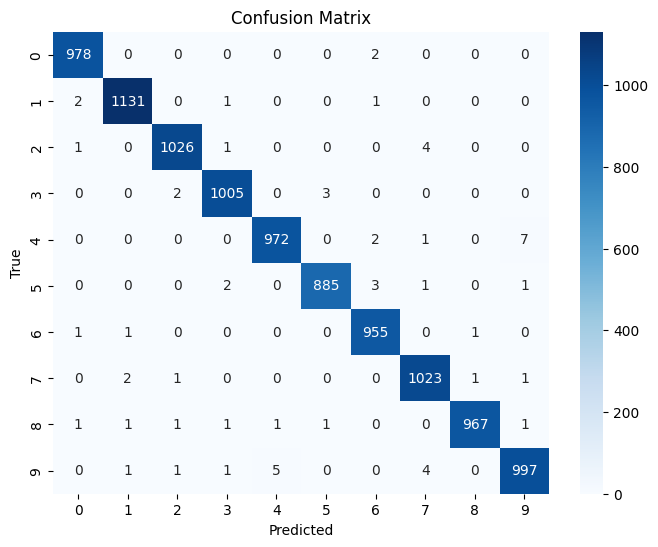

In [27]:
digit_metrics = evaluate_model_metrics(augmented_bn_do_model, X_test_digit_hog * 255, y_test_digit, num_classes=10)


In [33]:
train_dataset_early_stopping(augmented_bn_do_model, dataloader, epochs = 50, lr=0.0002, best_model_path='best_model.pth')


training
Epoch [1/50], Loss: 0.0299, Acc: 0.9906
New best model saved with validation loss: 0.0299
Epoch [2/50], Loss: 0.0309, Acc: 0.9897
Epoch [3/50], Loss: 0.0288, Acc: 0.9906
New best model saved with validation loss: 0.0288
Epoch [4/50], Loss: 0.0310, Acc: 0.9895
Epoch [5/50], Loss: 0.0298, Acc: 0.9906
Epoch [6/50], Loss: 0.0289, Acc: 0.9902
Epoch [7/50], Loss: 0.0292, Acc: 0.9906
Epoch [8/50], Loss: 0.0305, Acc: 0.9900


Accuracy: 0.9937
F1 Score: 0.9937
Precision: 0.9937
Recall: 0.9937


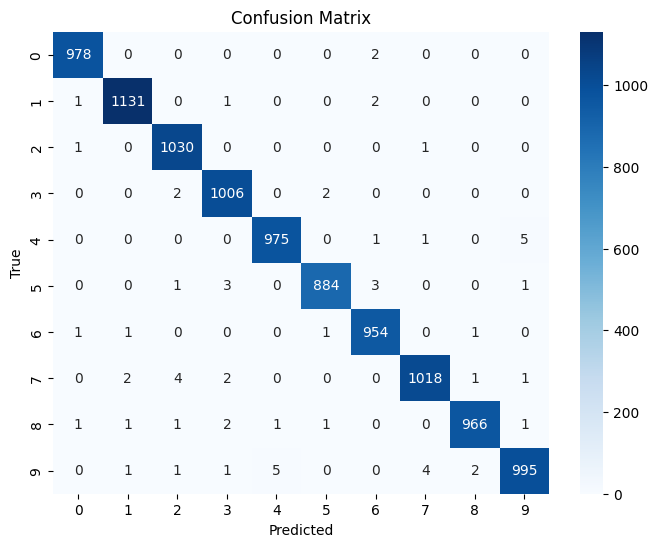

In [34]:
digit_metrics = evaluate_model_metrics(augmented_bn_do_model, X_test_digit_hog * 255, y_test_digit, num_classes=10)


Accuracy: 0.9939
F1 Score: 0.9939
Precision: 0.9939
Recall: 0.9939


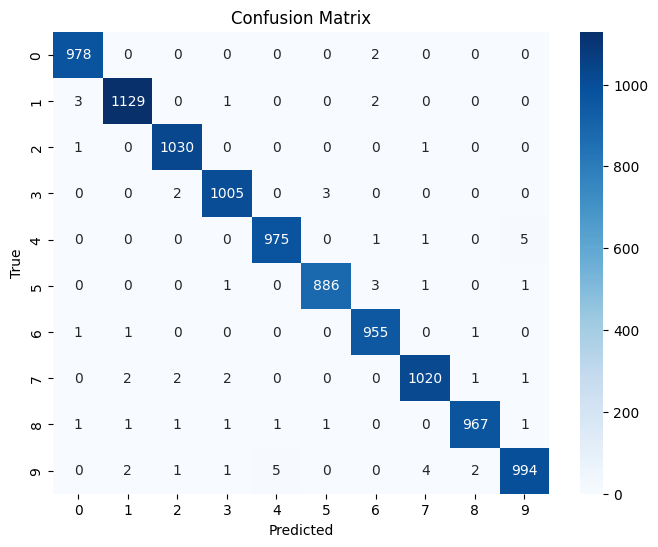

In [36]:
best_model_digit = baseline_ANN_2_hidden_layer(1296, 512, 10)
best_model_digit.load_state_dict(torch.load('best_model.pth'))
best_model_digit.to(device)
digit_metrics = evaluate_model_metrics(best_model_digit, X_test_digit_hog * 255, y_test_digit, num_classes=10)

# Model Cuối cùng, có lưu check points
Đạt kết quả tốt nhất trên tập test:
- Accuracy: 0.9939
- F1 Score: 0.9939
- Precision: 0.9939
- Recall: 0.9939